# Experiment - ResNet50 with focal loss (discarded)

ResNet50 with a custom `FocalLoss` and mask-aware preprocessing.

Discarded. Validation F1 peaked around 0.16, far below the plain cross-entropy baseline in `01_resnet50_whole_slide.ipynb`.

---


## Imports

In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain train_data/, test_data/ and train_labels.csv
# (see data/README.md).
import os

DATA_DIR = os.environ.get("WSI_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB


## Setup Paths

In [3]:
DRIVE_BASE_PATH = os.environ.get("WSI_DATA_DIR", "data")

# Paths to data folders and labels file in Drive
TRAIN_IMG_DIR = f'{DRIVE_BASE_PATH}/Dataset/train_img_data'
TRAIN_MASK_DIR = f'{DRIVE_BASE_PATH}/Dataset/train_mask_data'
TEST_DATA_DIR = f'{DRIVE_BASE_PATH}/Dataset/test_data'
TRAIN_LABELS_PATH = f'{DRIVE_BASE_PATH}/Dataset/train_labels.csv'

# Verify paths exist
print("="*70)
print("CHECKING DATA PATHS")
print("="*70)

if os.path.exists(TRAIN_IMG_DIR):
    train_img_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.png')]
    print(f"Train images folder found")
    print(f"Path: {TRAIN_IMG_DIR}")
    print(f"Total files: {len(train_img_files)}")
else:
    print(f"Train images folder NOT found at: {TRAIN_IMG_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_MASK_DIR):
    train_mask_files = [f for f in os.listdir(TRAIN_MASK_DIR) if f.endswith('.png')]
    print(f"\n Train masks folder found")
    print(f"Path: {TRAIN_MASK_DIR}")
    print(f"Total files: {len(train_mask_files)}")
else:
    print(f"\n Train masks folder NOT found at: {TRAIN_MASK_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TEST_DATA_DIR):
    test_files = [f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.png')]
    print(f"\n Test data folder found")
    print(f"Path: {TEST_DATA_DIR}")
    print(f"Total files: {len(test_files)}")
else:
    print(f"\n Test data folder NOT found at: {TEST_DATA_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_LABELS_PATH):
    print(f"\n Labels file found")
    print(f"Path: {TRAIN_LABELS_PATH}")
else:
    print(f"\n Labels file NOT found at: {TRAIN_LABELS_PATH}")
    print(f"Please check your Google Drive path!")

print("\n" + "="*70)
print("PATH VERIFICATION COMPLETED")
print("="*70)

CHECKING DATA PATHS
 Train images folder found
  Path: <working directory>
  Total files: 580

 Train masks folder found
  Path: <working directory>
  Total files: 580

 Test data folder found
  Path: <working directory>
  Total files: 954

 Labels file found
  Path: <working directory>

PATH VERIFICATION COMPLETED


## Data Preprocessing and Augmentation

Train dataset size: 580

First rows of the dataset:
   sample_index            label
0  img_0000.png  Triple negative
1  img_0002.png        Luminal B
2  img_0003.png        Luminal B
3  img_0004.png        Luminal B
4  img_0006.png        Luminal A

CLASS DISTRIBUTION
label
Luminal B          204
Luminal A          157
HER2(+)            150
Triple negative     69
Name: count, dtype: int64


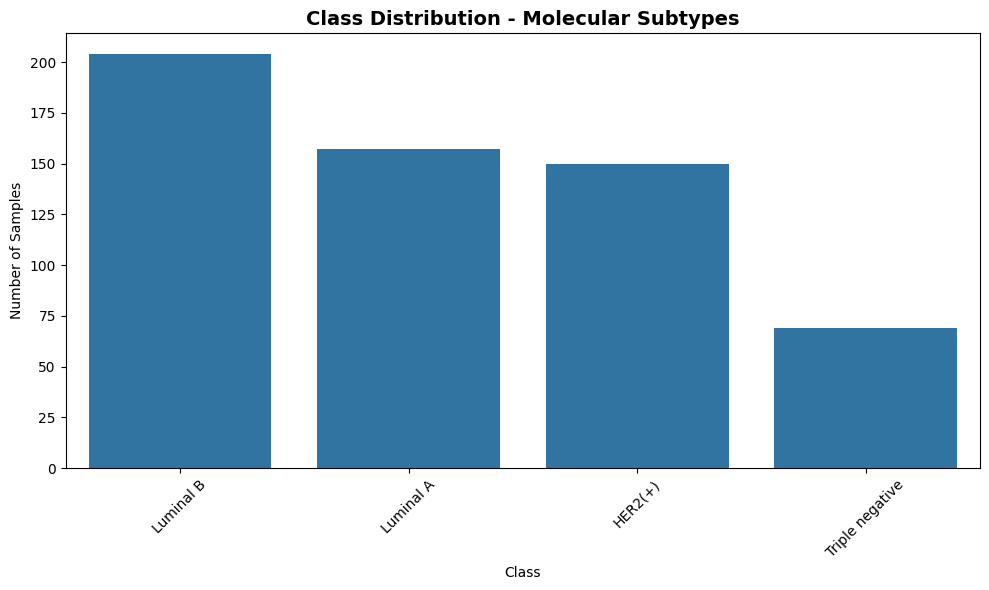


Number of classes: 4


In [4]:
# Load labels
train_labels = pd.read_csv(TRAIN_LABELS_PATH)
print(f"Train dataset size: {len(train_labels)}")
print("\nFirst rows of the dataset:")
print(train_labels.head())

# Class distribution analysis
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
class_counts = train_labels['label'].value_counts()
print(class_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution - Molecular Subtypes', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Class to index mapping
label_to_idx = {
    'Luminal A': 0,
    'Luminal B': 1,
    'HER2(+)': 2,
    'Triple negative': 3  # Corrected 'Triple Negative' to 'Triple negative' to match DataFrame
}
idx_to_label = {v: k for k, v in label_to_idx.items()}

print(f"\nNumber of classes: {len(label_to_idx)}")


Visualizing sample images and masks...


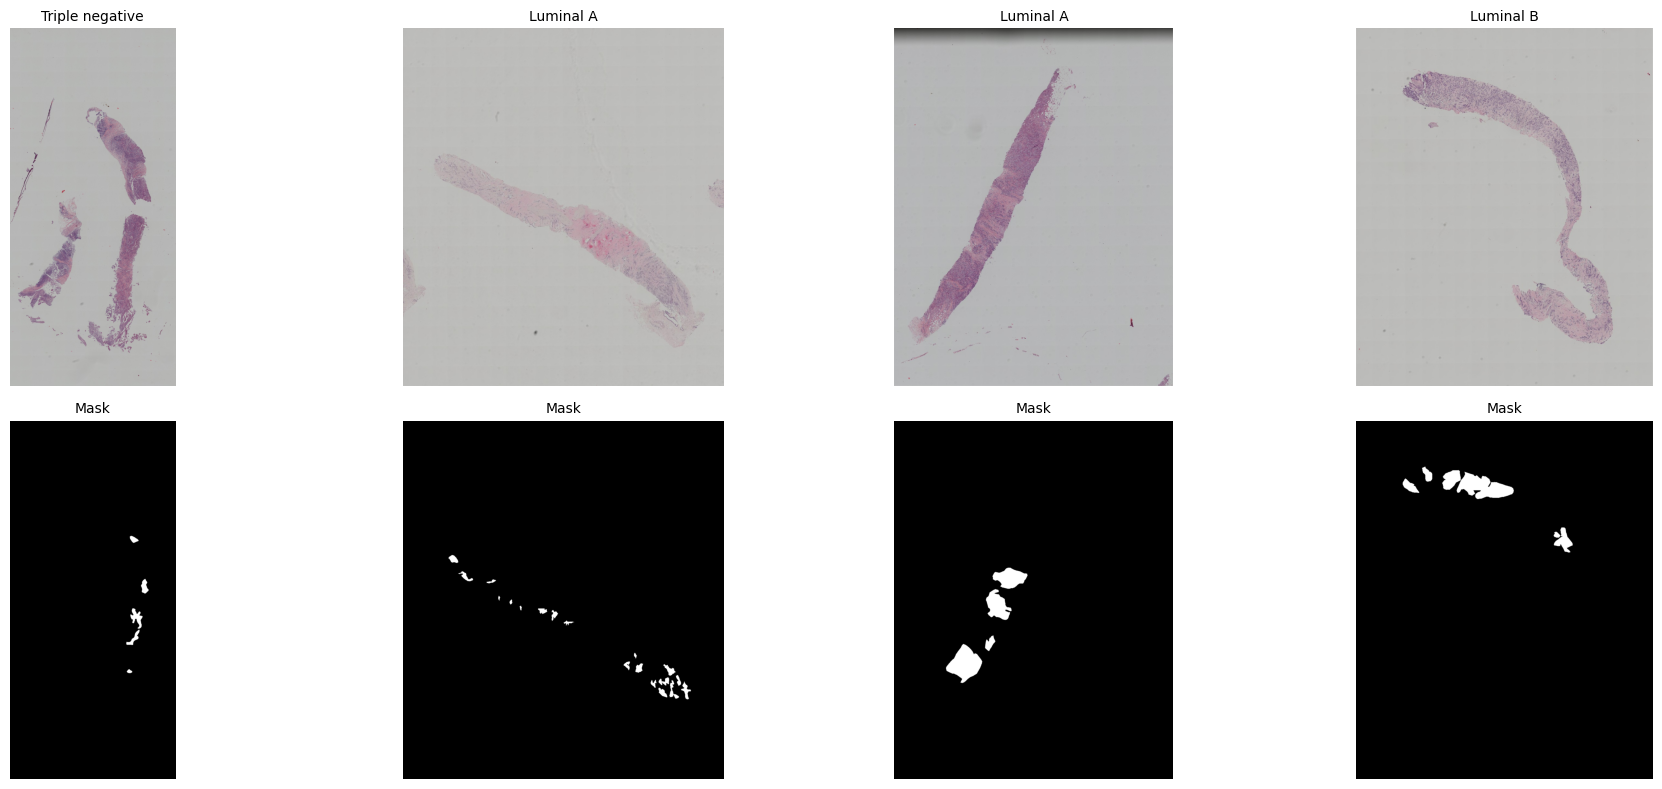

In [5]:
def visualize_samples(df, img_dir, mask_dir, n_samples=8, use_mask=True):
    """Visualize random samples with their masks"""
    if use_mask:
        fig, axes = plt.subplots(2, n_samples, figsize=(20, 8))
    else:
        fig, axes = plt.subplots(1, n_samples, figsize=(20, 4))
        axes = np.array([axes])  # Make it 2D for consistent indexing

    samples = df.sample(min(n_samples, len(df)))

    for idx, (_, row) in enumerate(samples.iterrows()):
        img_name = row['sample_index']
        label = row['label']

        # Load image
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)

        # Check if image was loaded successfully
        if img is None:
            print(f"Warning: Could not load image at {img_path}. Skipping.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f"{label}", fontsize=10)
        axes[0, idx].axis('off')

        # Load and display mask
        if use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    axes[1, idx].imshow(mask, cmap='gray')
                    axes[1, idx].set_title(f"Mask", fontsize=10)
                    axes[1, idx].axis('off')
                else:
                    print(f"Warning: Could not load mask at {mask_path}")
                    axes[1, idx].axis('off')
            else:
                print(f"Warning: Mask not found at {mask_path}")
                axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing sample images and masks...")
visualize_samples(train_labels, TRAIN_IMG_DIR, TRAIN_MASK_DIR, n_samples=4)

In [6]:
class TissueDataset(Dataset):
    """Custom Dataset for tissue images with optional mask support"""

    def __init__(self, df, img_dir, mask_dir, label_to_idx, transform=None, use_mask=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.label_to_idx = label_to_idx
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image ID and label
        img_name = self.df.loc[idx, 'sample_index']
        label = self.df.loc[idx, 'label']
        label_idx = self.label_to_idx[label]

        # Load image
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Optionally apply mask
        if self.use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(self.mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = mask / 255.0  # Normalize to [0, 1]
                mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
                img = img * mask  # Apply mask
                img = img.astype(np.uint8)

        # Apply transforms
        if self.transform:
            img = self.transform(img)

        return img, label_idx

class TestTissueDataset(Dataset):
    """Custom Dataset for test images (no labels)"""

    def __init__(self, image_files, data_dir, transform=None, use_mask=False):
        self.image_files = image_files
        self.data_dir = data_dir
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]

        # Load image
        img_path = os.path.join(self.data_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # For test data, masks might have same filename in test_data folder
        if self.use_mask:
            # Try to find corresponding mask (if exists)
            mask_file = img_file  # Assuming same filename for mask
            mask_path = os.path.join(self.data_dir, mask_file)

            if os.path.exists(mask_path) and 'mask' in mask_file.lower():
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = mask / 255.0
                mask = np.expand_dims(mask, axis=-1)
                img = img * mask
                img = img.astype(np.uint8)

        if self.transform:
            img = self.transform(img)

        return img, img_file

In [7]:
# Image size for the model
IMG_SIZE = 224

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [8]:
# Split data into train and validation sets
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels['label']
)

print(f"\nTrain size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

print("\nTrain class distribution:")
print(train_df['label'].value_counts())
print("\nValidation class distribution:")
print(val_df['label'].value_counts())

# Create datasets
USE_MASK = True

train_dataset = TissueDataset(
    train_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=train_transform, use_mask=USE_MASK
)

val_dataset = TissueDataset(
    val_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=val_transform, use_mask=USE_MASK
)

# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")


Train size: 464
Validation size: 116

Train class distribution:
label
Luminal B          163
Luminal A          126
HER2(+)            120
Triple negative     55
Name: count, dtype: int64

Validation class distribution:
label
Luminal B          41
Luminal A          31
HER2(+)            30
Triple negative    14
Name: count, dtype: int64

Number of training batches: 15
Number of validation batches: 4


## Model Definition

In [9]:
class TissueClassifier(nn.Module):
    """Transfer learning model using ResNet50"""

    def __init__(self, num_classes=4, pretrained=True):
        super(TissueClassifier, self).__init__()

        # Load pretrained ResNet50
        self.base_model = models.resnet50(pretrained=pretrained)

        # Get the number of features in the last layer
        num_features = self.base_model.fc.in_features

        # Replace the final fully connected layer
        self.base_model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

# Initialize model
model = TissueClassifier(num_classes=4, pretrained=True)
model = model.to(device)

# Print model summary
print("\nModel Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]



Model Architecture:
TissueClassifier(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (do

## Training Configuration

In [10]:
# Calculate class weights for imbalanced dataset
class_counts = train_df['label'].value_counts()
total_samples = len(train_df)
class_weights = {}

print("\n" + "="*50)
print("CLASS WEIGHTS CALCULATION")
print("="*50)
for label, count in class_counts.items():
    weight = total_samples / (len(class_counts) * count)
    class_weights[label] = weight
    print(f"{label:20s}: {count:4d} samples -> weight: {weight:.4f}")

# Convert to tensor
weights_list = [class_weights[idx_to_label[i]] for i in range(len(label_to_idx))]
class_weights_tensor = torch.FloatTensor(weights_list).to(device)

print(f"\nClass weights tensor: {class_weights_tensor}")

# Focal Loss implementation for imbalanced classification
class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma  # focusing parameter
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Loss function: Focal Loss with class weights
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

# Optimizer (Adam with weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Increased from 0.0001 to 0.001

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


CLASS WEIGHTS CALCULATION
Luminal B           :  163 samples -> weight: 0.7117
Luminal A           :  126 samples -> weight: 0.9206
HER2(+)             :  120 samples -> weight: 0.9667
Triple negative     :   55 samples -> weight: 2.1091

Class weights tensor: tensor([0.9206, 0.7117, 0.9667, 2.1091], device='cuda:0')


## Training Functions

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Update progress bar
        pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    # Calculate F1 Score (macro average)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, epoch_f1, all_preds, all_labels

## Training

In [12]:
# Training parameters
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

In [13]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_val_f1 = 0.0
patience_counter = 0

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, val_f1, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Print epoch summary
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val F1: {val_f1:.4f}")

    # Save best model based on F1 Score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved! (Val F1: {val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*70)
print(f"TRAINING COMPLETED - Best Val F1: {best_val_f1:.4f}")
print("="*70)


STARTING TRAINING

Epoch 1/20
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [02:18<00:00, 34.63s/it, loss=1.22, acc=25.9]



Train Loss: 0.9256 | Train Acc: 20.91%
Val Loss: 0.9770 | Val Acc: 25.86% | Val F1: 0.1629
 New best model saved! (Val F1: 0.1629)

Epoch 2/20
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:08<00:00,  2.23s/it, loss=0.783, acc=14.7]



Train Loss: 0.8790 | Train Acc: 17.46%
Val Loss: 0.8040 | Val Acc: 14.66% | Val F1: 0.0984

Epoch 3/20
----------------------------------------------------------------------


...


Train Loss: 0.8385 | Train Acc: 13.58%
Val Loss: 0.8154 | Val Acc: 12.07% | Val F1: 0.0538

Epoch 5/20
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:10<00:00,  2.53s/it, loss=0.794, acc=12.1]



Train Loss: 0.8247 | Train Acc: 12.72%
Val Loss: 0.8132 | Val Acc: 12.07% | Val F1: 0.0538

Epoch 6/20
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:09<00:00,  2.31s/it, loss=0.793, acc=12.1]


Train Loss: 0.8286 | Train Acc: 14.66%
Val Loss: 0.8140 | Val Acc: 12.07% | Val F1: 0.0538

Early stopping triggered after 6 epochs

TRAINING COMPLETED - Best Val F1: 0.1629


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot F1 Score
axes[2].plot(history['val_f1'], label='Val F1', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded for evaluation")

# Get predictions
_, _, final_f1, final_preds, final_labels = validate_epoch(model, val_loader, criterion, device)

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(final_labels, final_preds,
                          target_names=list(label_to_idx.keys())))

# Calculate and display F1 scores
print("\n" + "="*70)
print("F1 SCORES")
print("="*70)
print(f"F1 Score (Macro):    {f1_score(final_labels, final_preds, average='macro'):.4f}")
print(f"F1 Score (Weighted): {f1_score(final_labels, final_preds, average='weighted'):.4f}")
print(f"Accuracy:            {accuracy_score(final_labels, final_preds):.4f}")

# Confusion matrix
cm = confusion_matrix(final_labels, final_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_to_idx.keys()),
            yticklabels=list(label_to_idx.keys()))
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Inference

In [ ]:
# Get test image IDs (file names from test_data folder)
test_image_files = []
for file in os.listdir(TEST_DATA_DIR):
    if file.endswith('.png'):
        test_image_files.append(file)

print(f"\nNumber of test images: {len(test_image_files)}")

# Create test dataset and loader
test_dataset = TestTissueDataset(
    test_image_files, TEST_DATA_DIR,
    transform=val_transform, use_mask=USE_MASK
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

# Inference
model.eval()
test_predictions = []
test_ids = []

print("\nRunning inference on test set...")
with torch.no_grad():
    for images, img_names in tqdm(test_loader, desc='Test Inference'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_predictions.extend(predicted.cpu().numpy())
        test_ids.extend(img_names)

# Convert predictions to class labels
predicted_labels = [idx_to_label[idx] for idx in test_predictions]

# Create submission dataframe
submission_df = pd.DataFrame({
    'sample_index': test_ids,
    'label': predicted_labels
})

# Save submission
submission_df.to_csv('submission.csv', index=False)
print("\nSubmission file saved as 'submission.csv'")
print(f"\nFirst few predictions:")
print(submission_df.head(10))